# CryptoArbitrageGraph — Análise Técnica

Notebook de consolidação dos resultados do projeto (EDA2 — Grupo 18): visualização do
grafo de câmbio, heatmap das taxas, ciclos de arbitragem detectados e análise de
complexidade (Bellman-Ford próprio × NetworkX).

> Execute com o venv do projeto: `jupyter nbconvert --to notebook --execute --inplace notebooks/analysis.ipynb`

## 1. Setup

Carrega as taxas do dataset local (`MockClient`) e roda o pipeline de detecção.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))  # raiz do repo no path

from src.api.coingecko_client import MockClient
from src.arbitrage.graph_builder import build_graph
from src.arbitrage.detector import ArbitrageDetector

symbols = ['BTC', 'ETH', 'USDT', 'BNB', 'USD']
client = MockClient()
rates = client.get_rates(symbols)
detector = ArbitrageDetector(client)
opportunities = detector.detect(symbols)
print('Moedas:', symbols)
print('Oportunidades detectadas:', len(opportunities))

Moedas: ['BTC', 'ETH', 'USDT', 'BNB', 'USD']
Oportunidades detectadas: 1


## 2. Grafo de câmbio (interativo)

Renderizado com **pyvis (vis.js)** — o mesmo grafo bonito da CLI (`--graph`): nós são moedas,
arestas são taxas (passe o mouse para ver), e os **ciclos de arbitragem ficam em vermelho**.
Abaixo um *snapshot* estático; o HTML gerado é interativo (zoom, arrastar, clicar).

HTML interativo salvo em: analysis_graph.html  (abra no navegador para zoom/arrastar/clicar)


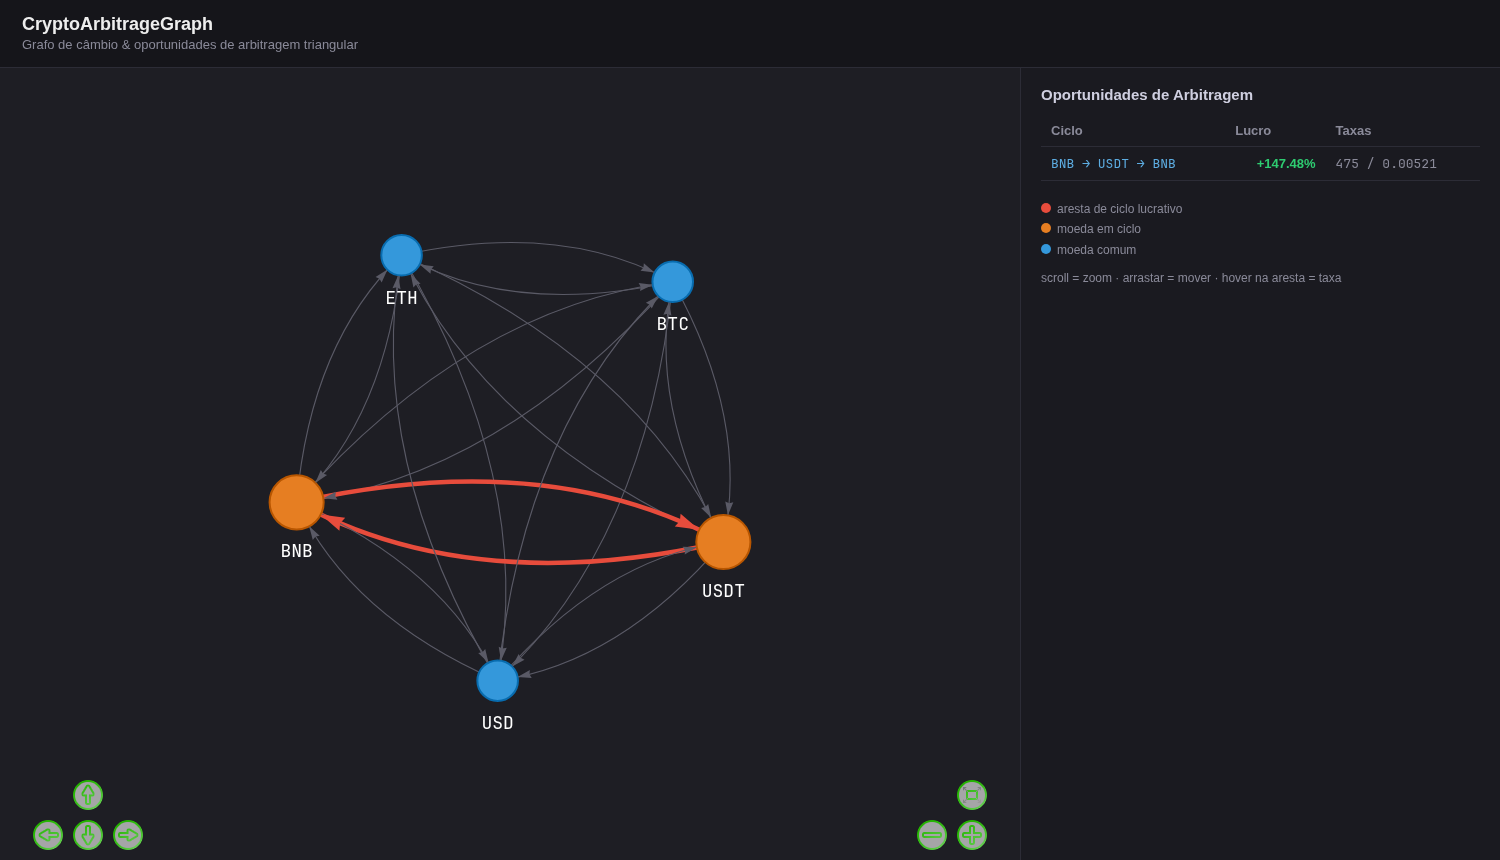

In [2]:
from src.visualize import build_graph_html
from IPython.display import Image, display

html_path = build_graph_html(rates, opportunities, 'analysis_graph.html', open_browser=False)
print(f'HTML interativo salvo em: {html_path}  (abra no navegador para zoom/arrastar/clicar)')
display(Image(filename='analysis_graph.png'))

## 3. Heatmap da matriz de taxas

As taxas variam por ordens de grandeza (ex.: 1 BTC ≈ 67000 USDT), então a cor usa
`log10(taxa)`. A diagonal fica vazia (não há taxa de uma moeda para ela mesma).

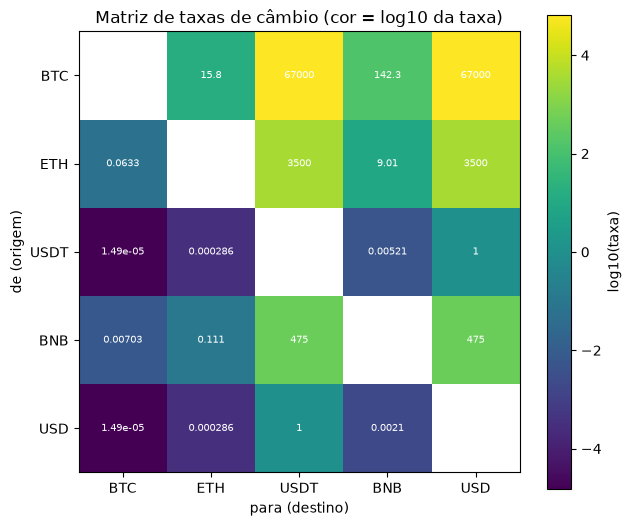

In [3]:
import numpy as np
import matplotlib.pyplot as plt

syms = list(rates.keys())
M = np.array([[rates[a].get(b, np.nan) for b in syms] for a in syms])

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(np.log10(M), cmap='viridis')
ax.set_xticks(range(len(syms))); ax.set_xticklabels(syms)
ax.set_yticks(range(len(syms))); ax.set_yticklabels(syms)
ax.set_xlabel('para (destino)'); ax.set_ylabel('de (origem)')
for i in range(len(syms)):
    for j in range(len(syms)):
        if not np.isnan(M[i, j]):
            ax.text(j, i, f'{M[i, j]:g}', ha='center', va='center', color='white', fontsize=7)
ax.set_title('Matriz de taxas de câmbio (cor = log10 da taxa)')
fig.colorbar(im, ax=ax, label='log10(taxa)')
plt.tight_layout(); plt.show()

## 4. Ciclos de arbitragem detectados

O detector roda Bellman-Ford a partir de cada nó e reporta os ciclos lucrativos
(produto das taxas > 1). No dataset local há um ciclo artificial plantado.

In [4]:
if not opportunities:
    print('Nenhuma oportunidade (mercado eficiente).')
for o in opportunities:
    ciclo = ' \u2192 '.join(o.cycle)
    taxas = ' / '.join(f'{r:g}' for r in o.rates_used)
    print(f'{ciclo}   |   lucro +{o.profit_pct:.2f}%   |   taxas {taxas}')

BNB → USDT → BNB   |   lucro +147.48%   |   taxas 475 / 0.00521


## 5. Complexidade — tempo × tamanho do grafo

Roda o benchmark (`src/benchmark/runner.py`) comparando o Bellman-Ford **próprio** com o
**NetworkX** em grafos densos de 5, 10, 20 e 50 nós. Escala vertical logarítmica (os tempos
diferem por ordens de grandeza).

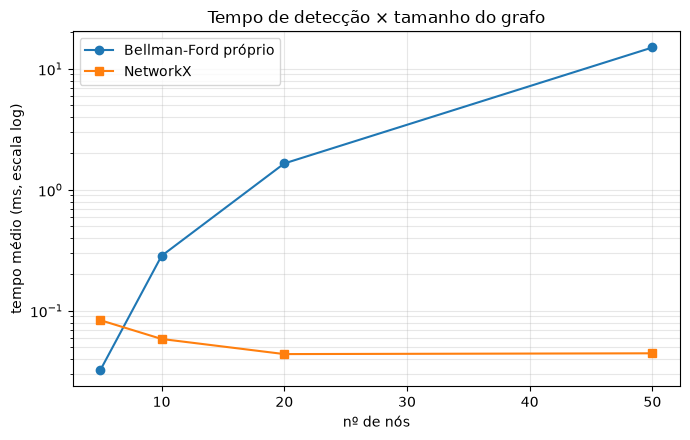

XS |  5 nós,   23 arestas | próprio   0.032 ms | NX  0.084 ms
 S | 10 nós,   93 arestas | próprio   0.285 ms | NX  0.059 ms
 M | 20 nós,  383 arestas | próprio   1.653 ms | NX  0.044 ms
 L | 50 nós, 2453 arestas | próprio  15.033 ms | NX  0.045 ms


In [5]:
from src.benchmark.runner import run_benchmark

res = run_benchmark()
nodes = [r.nodes for r in res]
own = [r.own_time_ms for r in res]
nxt = [r.nx_time_ms for r in res]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(nodes, own, 'o-', label='Bellman-Ford próprio')
ax.plot(nodes, nxt, 's-', label='NetworkX')
ax.set_yscale('log')
ax.set_xlabel('nº de nós'); ax.set_ylabel('tempo médio (ms, escala log)')
ax.set_title('Tempo de detecção × tamanho do grafo')
ax.grid(True, which='both', alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

for r in res:
    print(f'{r.label:>2} | {r.nodes:>2} nós, {r.edges:>4} arestas | próprio {r.own_time_ms:7.3f} ms | NX {r.nx_time_ms:6.3f} ms')

## 6. Discussão — quando o Bellman-Ford próprio vence vs perde

**Vence (grafos minúsculos, ~5 nós):** com pouquíssimas arestas, o overhead de montar o
`nx.DiGraph` e atravessar as camadas do NetworkX domina, e o laço puro do nosso algoritmo
sai na frente. Além disso, a implementação própria usa **~3× menos memória** em todos os
tamanhos (trabalha direto sobre listas/dicionários, sem a estrutura completa do `DiGraph`).

**Perde (a partir de ~10 nós):** a complexidade `O(V·E)` em **Python puro** — e o grafo
denso faz `E ≈ V²`, logo ~`O(V³)` — cresce rápido. O NetworkX roda os laços críticos em **C**
e termina cedo, então escala muito melhor (em 50 nós, ~300× mais rápido).

**Corretude:** idêntica — as duas implementações encontram o mesmo ciclo em todos os tamanhos.

**Trade-off:** para o escopo do projeto (poucas moedas → grafos pequenos), a implementação
própria é adequada, econômica e **transparente** (ótima para fins didáticos). Para produção
com grafos grandes, o NetworkX vence pela performance. Detalhes em `docs/benchmark_results.md`.